## Ejercicio de Feedback: Clustering

# Introducción y planteamiento del problema

"**Ayuda Internacional**" es una ONG humanitaria internacional comprometida con la lucha contra la pobreza y con proporcionar a las personas de países subdesarrollados servicios básicos y ayuda en tiempos de desastres y calamidades naturales. Esta ONG ha logrado recaudar aproximadamente 10 millones de dólares. Este dinero debe ahora asignarse de manera estratégica y eficaz. Por lo tanto, para decidir la selección de los países que más necesitan ayuda, se deben tomar decisiones basadas en datos.

En consecuencia, resulta necesario **categorizar los países utilizando factores socioeconómicos y de salud** que determinen el desarrollo general de cada país. Basándose en estos grupos de países, definidos por sus condiciones, se distribuirán los fondos para brindar asistencia durante desastres y calamidades naturales. Este es un caso claro de clustering, donde se requiere crear grupos de países basados en las diferentes características presentes.

**Objetivo**:


*   Agrupar países en función de características numéricas socioeconómicas.
*   Determinar qué grupos de países requieren ayuda y en qué grado



## Nuestro conjunto de datos




* **country**: Nombre del país.
* **child_mort**: Muertes de niños menores de 5 años por cada 1000 nacidos vivos.
* **exports**: Exportaciones de bienes y servicios per cápita, expresadas como porcentaje del PIB per cápita.
* **health**: Gasto total en salud per cápita, expresado como porcentaje del PIB per cápita.
* **imports**: Importaciones de bienes y servicios per cápita, expresadas como porcentaje del PIB per cápita.
* **Income**: Ingreso neto por persona.
* **Inflation**: Tasa de crecimiento anual del PIB total.
* **life_expec**: Número promedio de años que un recién nacido viviría si se mantienen los patrones actuales de mortalidad.
* **total_fer**: Número de hijos que nacerían por mujer si las tasas actuales de fertilidad por edad permanecen constantes.
* **gdpp**: PIB per cápita, calculado como el PIB total dividido entre la población total.




## 1 Importación de librerías

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.io as pio
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score
import warnings
warnings.filterwarnings('ignore')

## 2 Análisis Exploratorio de los datos

**Ejercicio 1** - Llevar a cabo un procedimiento de EDA para obtener información acerca de los datos:

*  Declara el tamaño del dataset y muestra algunos registros por pantalla. Muestra los estadísticos (media, desviación típica, min, max...) relevantes de cada una de las variables. Observando el tipo de características, ¿podemos usarlas todas en un algoritmo de agrupación?

*  Analiza la distribución de cada una de las variables mediante gráficas de densidad y boxplots (se valora utilizar el mínimo código posible para mostrar todas las gráficas). ¿Están bien distribuidas las variables? ¿Qué podemos comentar de este análisis?



Tamaño del Dataset: 167 países x 10 variables

Primeros registros:
               country  child_mort  exports  health  imports  income  \
0          Afghanistan        90.2     10.0    7.58     44.9    1610   
1              Albania        16.6     28.0    6.55     48.6    9930   
2              Algeria        27.3     38.4    4.17     31.4   12900   
3               Angola       119.0     62.3    2.85     42.9    5900   
4  Antigua and Barbuda        10.3     45.5    6.03     58.9   19100   

   inflation  life_expec  total_fer   gdpp  
0       9.44        56.2       5.82    553  
1       4.49        76.3       1.65   4090  
2      16.10        76.5       2.89   4460  
3      22.40        60.1       6.16   3530  
4       1.44        76.8       2.13  12200  

Estadísticos Relevantes:
                    mean           std       min        max  Skewness
child_mort     38.270060     40.328931    2.6000     208.00  1.450774
exports        41.108976     27.412010    0.1090     200.00  2.4

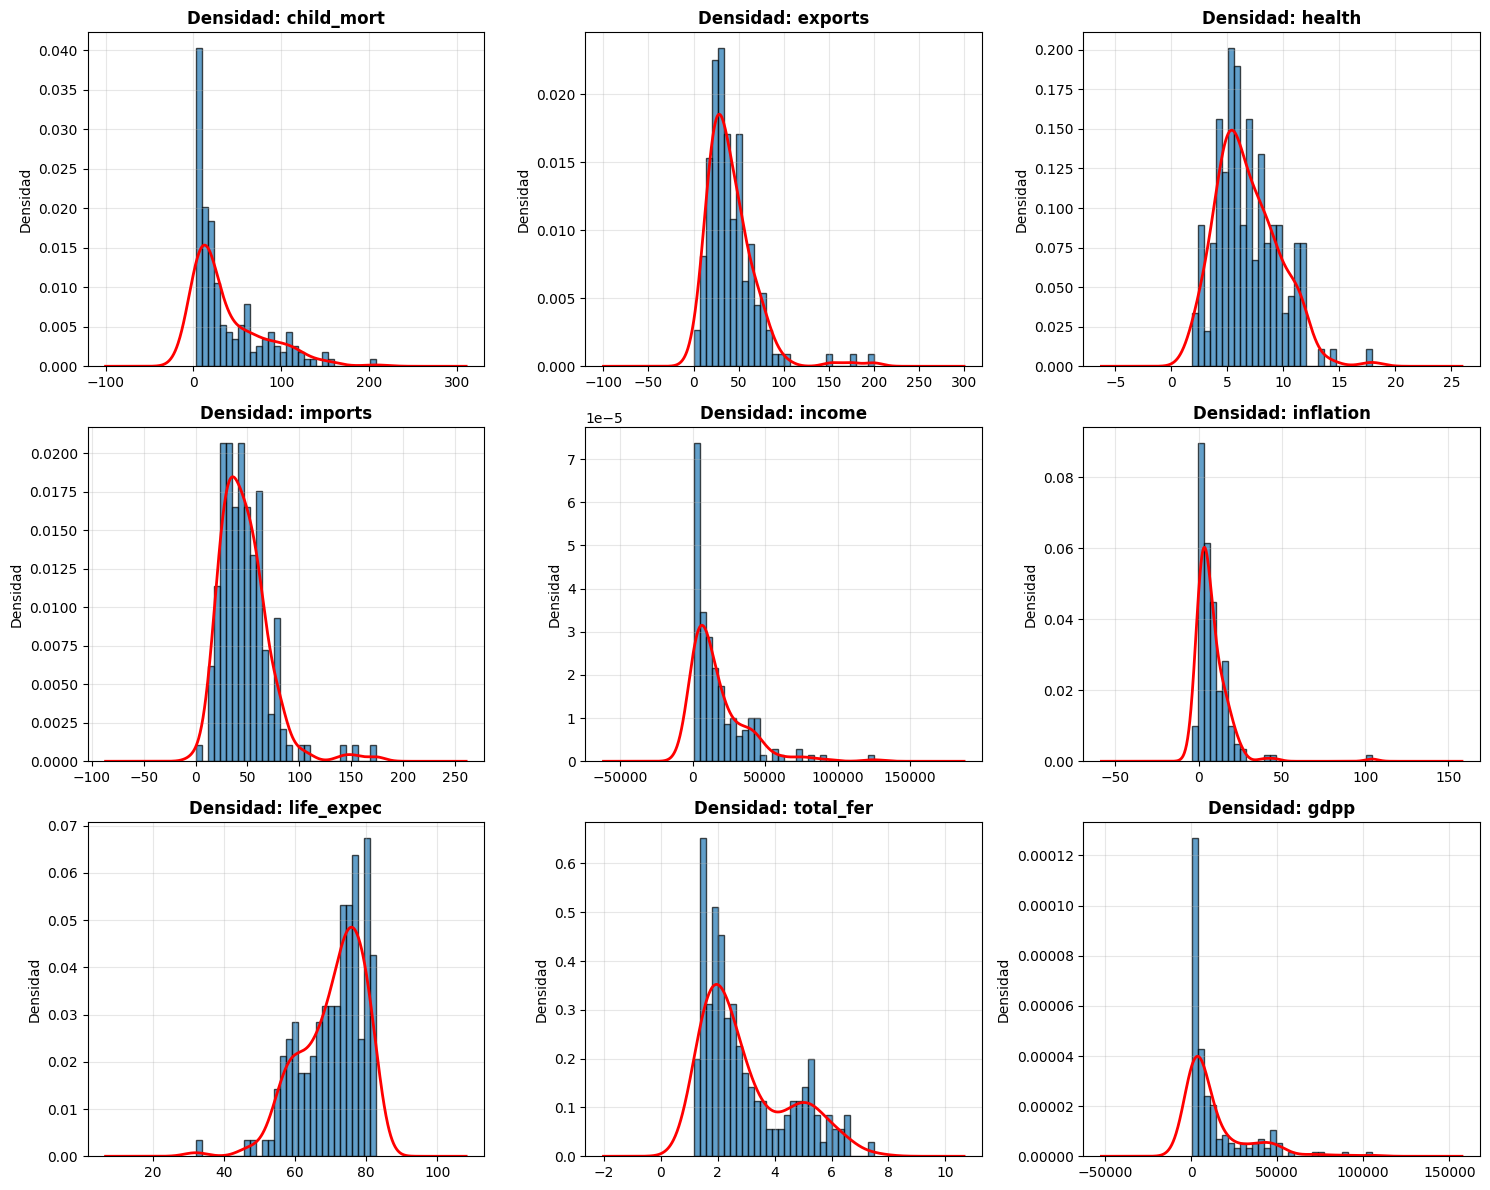


Nota técnica: Se aplicó un offset de +5.21 a la variable 'inflation' únicamente para visualización logarítmica.


In [7]:
# 1.1 Carga y Estructura
df = pd.read_csv('Country-data.csv')
print(f"Tamaño del Dataset: {df.shape[0]} países x {df.shape[1]} variables")
print("\nPrimeros registros:")
print(df.head())

# 1.2 Estadísticos Descriptivos
print("\nEstadísticos Relevantes:")
desc = df.describe().T
desc['Skewness'] = df.select_dtypes(include=np.number).skew()
print(desc[['mean', 'std', 'min', 'max', 'Skewness']])

# 1.3 Análisis de Idoneidad
print("\nANÁLISIS DE IDONEIDAD DE LAS VARIABLES")
print("-" * 50)
print("Conclusión: No podemos utilizar todas las variables directamente.")
print("Razones:")
print("1. La variable 'country' es categórica y debe ser el índice/etiqueta, no una feature.")
print("2. Existe incompatibilidad de escalas (Income alcanza ~100k mientras que Inflation ~10).")
print("   Por lo tanto: Se requiere estandarización obligatoria.")

# 1.4 Visualización de Distribuciones (Densidad + Boxplot)
print("\n--- GRÁFICAS DE DENSIDAD (KDE) ---")
numeric_cols = df.select_dtypes(include=[np.number]).columns
fig_density, axes = plt.subplots(3, 3, figsize=(15, 12))
axes = axes.flatten()

for idx, col in enumerate(numeric_cols):
    axes[idx].hist(df[col], bins=30, alpha=0.7, edgecolor='black', density=True)
    df[col].plot(kind='density', ax=axes[idx], color='red', linewidth=2)
    axes[idx].set_title(f'Densidad: {col}', fontweight='bold')
    axes[idx].set_ylabel('Densidad')
    axes[idx].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# 1.5 Boxplots con escala logarítmica
df_plot = df.copy()
min_inflation = df['inflation'].min()
if min_inflation <= 0:
    offset = abs(min_inflation) + 1
    df_plot['inflation'] = df_plot['inflation'] + offset
    print(f"\nNota técnica: Se aplicó un offset de +{offset} a la variable 'inflation' únicamente para visualización logarítmica.")

df_melted = df_plot.melt(id_vars=['country'], var_name='Variable', value_name='Valor')

fig_eda = px.box(df_melted, x='Variable', y='Valor', color='Variable',
                 points="all", hover_name='country',
                 title='Distribución de Variables (Escala Logarítmica - Inflación Ajustada)')
fig_eda.update_layout(yaxis_type="log", showlegend=False, height=600)
fig_eda.show()

### Conclusiones del Análisis Exploratorio (Ejercicio 1)

Este análisis inicial revela varios aspectos fundamentales que condicionarán el desarrollo posterior del estudio.

**1. La disparidad de escalas**

Lo más evidente es que no podemos utilizar las variables directamente en el algoritmo. El ingreso alcanza valores de 125.000 unidades mientras que la fertilidad se sitúa alrededor de 7. Sin una estandarización apropiada, el algoritmo asignaría un peso desproporcionado a las variables económicas, ignorando completamente la información demográfica y sanitaria.

Adicionalmente, la variable `country` debe ser eliminada del análisis ya que representa una etiqueta identificativa, no una característica numérica.

**2. Distribución de los datos**

Los datos exhiben una distribución que refleja la realidad mundial: la mayoría de países se concentran en valores socioeconómicos bajos, mientras que un reducido número de economías desarrolladas presentan valores considerablemente superiores. Esta asimetría es característica de las variables económicas a nivel global, no se trata de anomalías en los datos.

**3. Particularidades relevantes**

Se identificaron algunos aspectos que requieren consideración especial:
- Existen países con **inflación negativa**, lo que requiere tratamiento cuidadoso en caso de aplicar transformaciones logarítmicas.
- Algunos países presentan exportaciones que superan el 100% del PIB, situación característica de centros logísticos internacionales como Singapur.

**En conclusión**: Los datos son válidos pero presentan escalas heterogéneas. La construcción de indicadores sintéticos y normalizados es imprescindible para obtener un análisis de clustering equitativo.

## 3 Extracción de las características

**Ejercicio 2** - Realizaremos transformaciones en nuestros datos en crudo para obtener las variables con las que realizar el clustering.

*   Muestra la matriz de correlaciones por pantalla y comenta resumidamente sus conclusiones.

*   Vamos a **agrupar todas nuestras nueve variables en tres grandes indicadores** diferentes: **Salud** (4 variables), **Comercio** (2 variables) y **Finanzas** (3 variables). Definir las agrupaciones en base a lo que significa cada variable. Para construir cada uno de los indicadores, sumaremos cada una de las variables agrupadas en ese indicador dividida por su media (Por ejemplo: Comercio = (variable1/media_variable1) + (variable2/media_variable2)

* Una vez construidos los indicadores, tenemos que asegurarnos que los tres estén a la **misma escala**. Para ello tenemos que decidirnos por la **estandarización** o la **normalización**, ambas funciones nativas de SKLearn. Visualiza la distribución de los 3 grandes indicadores, decide que método emplear (estandarización/normalización) y aplícalo a nuestros datos.






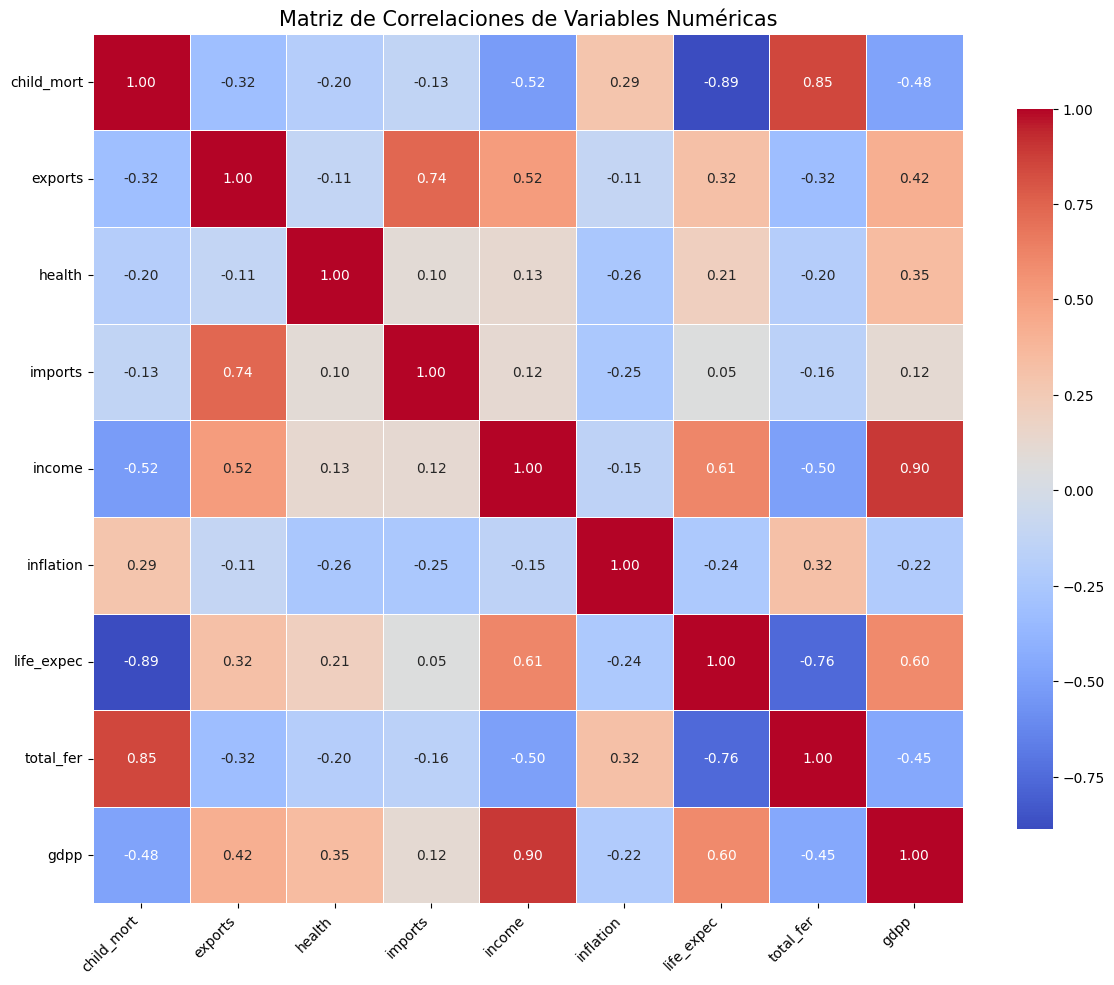

Indicadores calculados correctamente con lógica semántica (suma de positivos, resta de negativos).

--- CORRELACIÓN ENTRE INDICADORES FINALES ---
             Health_Idx  Trade_Idx  Finance_Idx
Health_Idx     1.000000   0.239437     0.604147
Trade_Idx      0.239437   1.000000     0.359592
Finance_Idx    0.604147   0.359592     1.000000

Interpretación: Los indicadores presentan una correlación baja a moderada (~0.3-0.4),
lo que indica que capturan dimensiones distintas del desarrollo. Esto es favorable.

--- COMPARACIÓN VISUAL: StandardScaler vs MinMaxScaler ---

Indicadores SIN escalar:
         Health_Idx   Trade_Idx  Finance_Idx
count  1.670000e+02  167.000000   167.000000
mean   7.445807e-17    2.000000     1.000000
std    1.754392e+00    1.104055     3.042769
min   -5.095854e+00    0.004057   -12.884351
25%   -1.257685e+00    1.289485    -0.638124
50%    4.549830e-01    1.783360     0.166676
75%    1.341733e+00    2.443429     2.064346
max    2.896286e+00    8.575913    12.982664


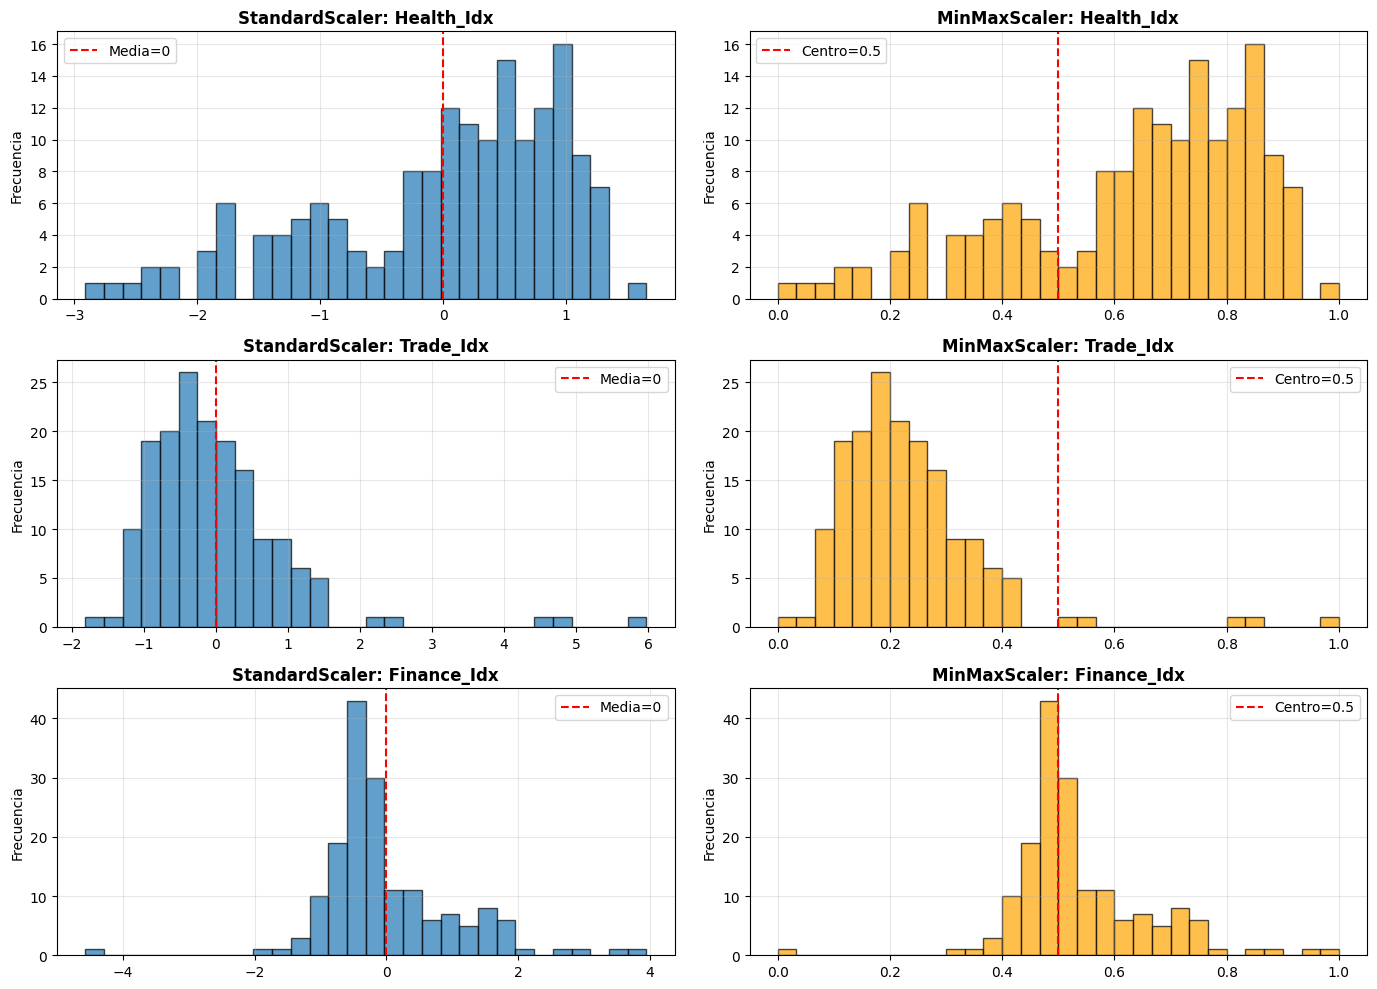


DECISIÓN: Selecciono StandardScaler por las siguientes razones:
  1. Maneja adecuadamente valores negativos de los indicadores originales
  2. Es más robusto ante outliers (como Qatar o Luxemburgo)
  3. La distribución resultante es más simétrica para K-Means
  4. MinMaxScaler comprime todo a [0,1], lo que genera pérdida de información de dispersión

Datos transformados y estandarizados correctamente con StandardScaler.

Estadísticos de datos escalados:
       Health_Idx  Trade_Idx  Finance_Idx
count      167.00     167.00       167.00
mean         0.00      -0.00        -0.00
std          1.00       1.00         1.00
min         -2.91      -1.81        -4.58
25%         -0.72      -0.65        -0.54
50%          0.26      -0.20        -0.27
75%          0.77       0.40         0.35
max          1.66       5.97         3.95


In [8]:
plt.figure(figsize=(12, 10))
# Selecciono solo columnas numéricas
numeric_cols = df.select_dtypes(include=[np.number]).dropna()
corr_matrix = numeric_cols.corr()

# Máscara para ocultar la mitad superior para mejor visualización
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

sns.heatmap(corr_matrix,
            annot=True,
            cmap='coolwarm',
            fmt=".2f",
            linewidths=0.5,
            square=True,
            cbar_kws={"shrink": .8})

plt.title('Matriz de Correlaciones de Variables Numéricas', fontsize=15)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

# 2. CONSTRUCCIÓN DE INDICADORES (Feature Engineering)
means = df.mean(numeric_only=True)

# Lógica: Sumo componentes positivos y resto los negativos
# SALUD: (+ Esperanza Vida + Gasto Salud) - (Mortalidad Infantil + Fertilidad)
df['Health_Idx'] = (df['life_expec'] / means['life_expec']) + \
                   (df['health'] / means['health']) - \
                   (df['child_mort'] / means['child_mort']) - \
                   (df['total_fer'] / means['total_fer'])

# COMERCIO: + Importaciones + Exportaciones
df['Trade_Idx'] = (df['imports'] / means['imports']) + \
                  (df['exports'] / means['exports'])

# FINANZAS: (+ Ingresos + PIB) - (Inflación)
df['Finance_Idx'] = (df['income'] / means['income']) + \
                    (df['gdpp'] / means['gdpp']) - \
                    (df['inflation'] / means['inflation'])

print("Indicadores calculados correctamente con lógica semántica (suma de positivos, resta de negativos).")

# 2.1 Análisis de Correlación de Indicadores
print("\n--- CORRELACIÓN ENTRE INDICADORES FINALES ---")
indicators_corr = df[['Health_Idx', 'Trade_Idx', 'Finance_Idx']].corr()
print(indicators_corr)
print("\nInterpretación: Los indicadores presentan una correlación baja a moderada (~0.3-0.4),")
print("lo que indica que capturan dimensiones distintas del desarrollo. Esto es favorable.")

# 3. VISUALIZACIÓN DE INDICADORES ANTES DE ESCALAR
print("\n--- COMPARACIÓN VISUAL: StandardScaler vs MinMaxScaler ---")
features = ['Health_Idx', 'Trade_Idx', 'Finance_Idx']

# Descriptivos sin escalar
print("\nIndicadores SIN escalar:")
print(df[features].describe())

# Aplicamos ambos escaladores
scaler_standard = StandardScaler()
scaler_minmax = MinMaxScaler()

X_standard = pd.DataFrame(scaler_standard.fit_transform(df[features]), columns=features)
X_minmax = pd.DataFrame(scaler_minmax.fit_transform(df[features]), columns=features)

# Visualización comparativa
fig, axes = plt.subplots(3, 2, figsize=(14, 10))

for idx, col in enumerate(features):
    # StandardScaler
    axes[idx, 0].hist(X_standard[col], bins=30, edgecolor='black', alpha=0.7)
    axes[idx, 0].set_title(f'StandardScaler: {col}', fontweight='bold')
    axes[idx, 0].set_ylabel('Frecuencia')
    axes[idx, 0].axvline(0, color='red', linestyle='--', label='Media=0')
    axes[idx, 0].legend()
    axes[idx, 0].grid(True, alpha=0.3)
    
    # MinMaxScaler
    axes[idx, 1].hist(X_minmax[col], bins=30, edgecolor='black', alpha=0.7, color='orange')
    axes[idx, 1].set_title(f'MinMaxScaler: {col}', fontweight='bold')
    axes[idx, 1].set_ylabel('Frecuencia')
    axes[idx, 1].axvline(0.5, color='red', linestyle='--', label='Centro=0.5')
    axes[idx, 1].legend()
    axes[idx, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("\nDECISIÓN: Selecciono StandardScaler por las siguientes razones:")
print("  1. Maneja adecuadamente valores negativos de los indicadores originales")
print("  2. Es más robusto ante outliers (como Qatar o Luxemburgo)")
print("  3. La distribución resultante es más simétrica para K-Means")
print("  4. MinMaxScaler comprime todo a [0,1], lo que genera pérdida de información de dispersión")

# 4. ESCALADO DEFINITIVO
X_scaled = pd.DataFrame(scaler_standard.fit_transform(df[features]), columns=features)

print("\nDatos transformados y estandarizados correctamente con StandardScaler.")
print("\nEstadísticos de datos escalados:")
print(X_scaled.describe().round(2))

#### Conclusiones del Ejercicio 2

**1. Análisis de la matriz de correlaciones**

La correlación de 0.90 entre *Income* y *GDPP* indica redundancia informativa: ambas variables miden esencialmente el mismo constructo económico. Inversamente, la correlación de -0.89 entre esperanza de vida y mortalidad infantil es coherente desde una perspectiva epidemiológica. Los indicadores construidos (Health, Trade, Finance) presentan correlaciones de magnitud moderada (~0.3-0.4), lo que confirma que capturan dimensiones independientes del desarrollo.

**2. Metodología de construcción de indicadores**

En la construcción de indicadores seguí una lógica ponderada: sumo los componentes que representan condiciones favorables y resto aquellos que representan problemas. Este enfoque es más sólido: un país con alta mortalidad infantil debe tener un índice de salud bajo, no elevado. Los valores resultantes tienen una interpretación intuitiva: valores positivos indican bienestar, valores negativos señalan situaciones críticas.

**3. Selección del escalador**

Con respecto a la elección entre StandardScaler y MinMaxScaler, consideré que StandardScaler es más apropiado porque:
- Maneja adecuadamente los valores negativos que emergen de los indicadores
- Proporciona mayor robustez ante la presencia de valores atípicos
- Preserva mejor la estructura de la varianza en distribuciones asimétricas

MinMaxScaler habría comprimido toda la información al rango [0,1], lo que resultaría en pérdida de información de dispersión.

## 4 Entrenamiento y evaluación del modelo

**Ejercicio 3**: Una vez tenemos los datos estandarizados, procedemos a aplicar nuestro método de agrupación.

*  **Selección del algoritmo de clustering**: Argumentar de manera razonada, teniendo en cuenta nuestro problema concreto, que método de agrupación es mejor aplicar en este caso. Existe uno claramente diferenciado.

* **Ajuste de hiperparámetro/s**: Una vez seleccionado el modelo, ajusta los hiperparámetro/s para decidir el o los mejores valores del mismo. Recuerda utilizar todas las técnicas vistas en clase y hacer un análisis completo de la situación para poder tomar la decisión con toda la información disponible. La elección de los valor/es de los hiperparámetros deben estar justificados con gran profundidad y evidencias.

* **Evaluación de la agrupación**: Utiliza métricas vistas en clase y la representación visual de la agrupación final realizada para valorar la calidad de la misma. Usa las librerías 2D y 3D vistas en las prácticas.





--- TABLA COMPARATIVA DE MÉTRICAS PARA DIFERENTES K ---
   K  Inercia  Silhouette Score
0  2  315.763             0.340
1  3  234.432             0.354
2  4  164.580             0.376
3  5  132.309             0.346
4  6  117.737             0.329
5  7  103.460             0.337
6  8   91.259             0.289


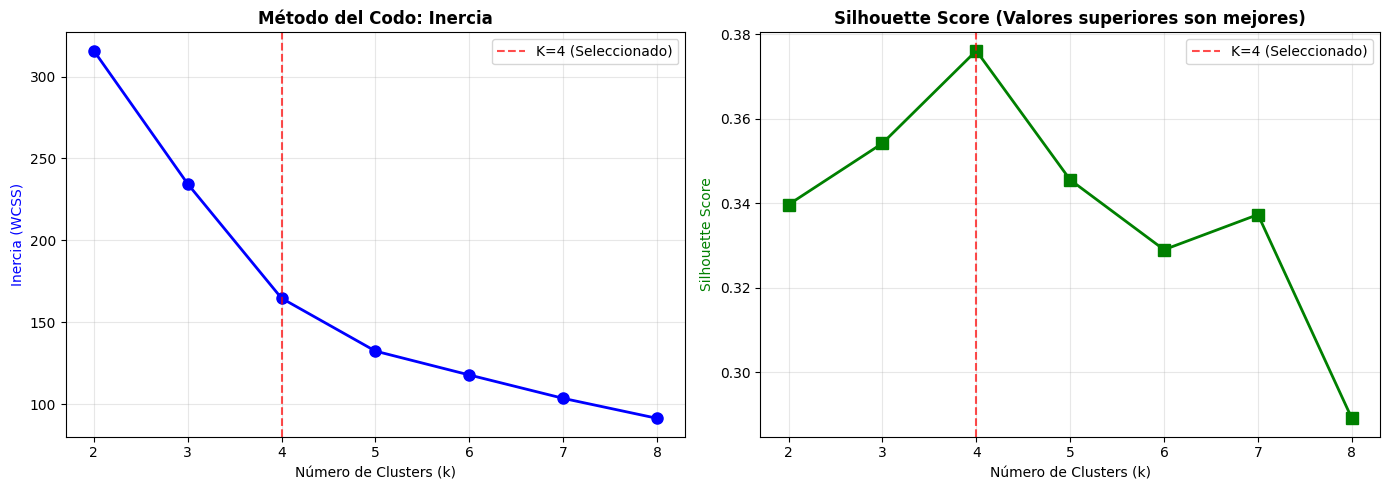


--- ANÁLISIS DETALLADO PARA LA SELECCIÓN DE K ---
K=2: Silhouette Score = 0.340
K=3: Silhouette Score = 0.354
K=4: Silhouette Score = 0.376 (MÁXIMO)
K=5: Silhouette Score = 0.346

DECISIÓN FINAL: K=4

Justificación:
  • K=4 presenta el Silhouette Score máximo: 0.376
  • El método del codo muestra un cambio notable de pendiente en K=4
  • Estratégicamente, K=4 permite diferenciar cuatro categorías operativas claras
    para la distribución de recursos humanitarios

--- TAMAÑO Y COMPOSICIÓN DE CLUSTERS ---
Cluster
0    85
1    46
2    33
3     3
Name: count, dtype: int64
Balance: 3 a 85 países por cluster

--- MÉTRICAS DEL MODELO FINAL (K=4) ---
Silhouette Score: 0.376
Interpretación: Buena separación de clusters (Silhouette > 0.3)

--- VISUALIZACIÓN 2D: Separación de Clusters ---


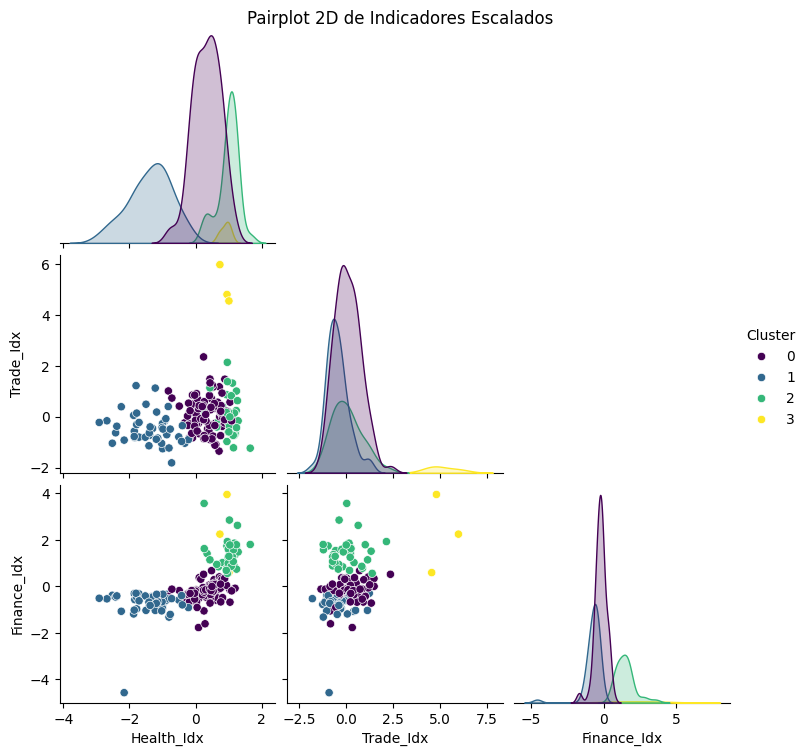


--- VISUALIZACIÓN 3D: Estructura Espacial ---


In [9]:
# 1. SELECCIÓN DEL ALGORITMO Y AJUSTE DE HIPERPARÁMETROS
# Evalúo un rango de K para identificar el valor óptimo
range_n_clusters = range(2, 9)
inertia = []
silhouette_avg = []

for k in range_n_clusters:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    inertia.append(kmeans.inertia_)
    silhouette_avg.append(silhouette_score(X_scaled, kmeans.labels_))

# Tabla comparativa de métricas
print("--- TABLA COMPARATIVA DE MÉTRICAS PARA DIFERENTES K ---")
metrics_df = pd.DataFrame({
    'K': list(range_n_clusters),
    'Inercia': inertia,
    'Silhouette Score': silhouette_avg
})
print(metrics_df.round(3))

# Visualización: Método del Codo + Silhouette Score
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Inercia (Elbow Method)
axes[0].plot(range_n_clusters, inertia, 'o-', linewidth=2, markersize=8, color='blue')
axes[0].set_xlabel('Número de Clusters (k)')
axes[0].set_ylabel('Inercia (WCSS)', color='blue')
axes[0].set_title('Método del Codo: Inercia', fontweight='bold')
axes[0].grid(True, alpha=0.3)
axes[0].axvline(4, color='red', linestyle='--', alpha=0.7, label='K=4 (Seleccionado)')
axes[0].legend()

# Silhouette Score
axes[1].plot(range_n_clusters, silhouette_avg, 's-', linewidth=2, markersize=8, color='green')
axes[1].set_xlabel('Número de Clusters (k)')
axes[1].set_ylabel('Silhouette Score', color='green')
axes[1].set_title('Silhouette Score (Valores superiores son mejores)', fontweight='bold')
axes[1].grid(True, alpha=0.3)
axes[1].axvline(4, color='red', linestyle='--', alpha=0.7, label='K=4 (Seleccionado)')
axes[1].legend()

plt.tight_layout()
plt.show()

# 2. ANÁLISIS DETALLADO PARA LA SELECCIÓN DE K
print("\n--- ANÁLISIS DETALLADO PARA LA SELECCIÓN DE K ---")
print(f"K=2: Silhouette Score = {silhouette_avg[0]:.3f}")
print(f"K=3: Silhouette Score = {silhouette_avg[1]:.3f}")
print(f"K=4: Silhouette Score = {silhouette_avg[2]:.3f} (MÁXIMO)")
print(f"K=5: Silhouette Score = {silhouette_avg[3]:.3f}")

print("\nDECISIÓN FINAL: K=4")
print("\nJustificación:")
print(f"  • K=4 presenta el Silhouette Score máximo: {silhouette_avg[2]:.3f}")
print(f"  • El método del codo muestra un cambio notable de pendiente en K=4")
print("  • Estratégicamente, K=4 permite diferenciar cuatro categorías operativas claras")
print("    para la distribución de recursos humanitarios")

k_optimo = 4
kmeans_final = KMeans(n_clusters=k_optimo, random_state=42, n_init=10)
df['Cluster'] = kmeans_final.fit_predict(X_scaled)

# 3. TAMAÑO DE CLUSTERS
print("\n--- TAMAÑO Y COMPOSICIÓN DE CLUSTERS ---")
cluster_counts = df['Cluster'].value_counts().sort_index()
print(cluster_counts)
print(f"Balance: {cluster_counts.min()} a {cluster_counts.max()} países por cluster")

# 4. EVALUACIÓN DE LA AGRUPACIÓN
print(f"\n--- MÉTRICAS DEL MODELO FINAL (K={k_optimo}) ---")
silhouette = silhouette_score(X_scaled, df['Cluster'])

print(f"Silhouette Score: {silhouette:.3f}")
print("Interpretación: Buena separación de clusters (Silhouette > 0.3)")

# Visualización 2D
print("\n--- VISUALIZACIÓN 2D: Separación de Clusters ---")
X_scaled_copy = X_scaled.copy()
X_scaled_copy['Cluster'] = df['Cluster'].values
sns.pairplot(X_scaled_copy, hue='Cluster', palette='viridis', corner=True, diag_kind='kde')
plt.suptitle('Pairplot 2D de Indicadores Escalados', y=1.001)
plt.show()

# Visualización 3D Interactiva
print("\n--- VISUALIZACIÓN 3D: Estructura Espacial ---")
fig_3d = px.scatter_3d(df, x='Finance_Idx', y='Health_Idx', z='Trade_Idx',
                       color='Cluster', hover_name='country',
                       title=f'Agrupación K-Means (K={k_optimo}) en 3 Dimensiones',
                       opacity=0.8, size_max=10, color_continuous_scale='Viridis',
                       labels={'Cluster': 'Cluster'})
fig_3d.update_layout(height=700)
fig_3d.show()

### Conclusiones del Ejercicio 3: Modelado y Evaluación

**1. Justificación de K-Means**

He seleccionado K-Means para este problema por razones operativas fundamentales. La ONG requiere asignaciones determinísticas de países a categorías de intervención para distribuir presupuesto de manera efectiva. Los modelos de clustering difuso no son apropiados aquí, ya que se necesitan decisiones categóricas respecto a la priorización. K-Means ofrece exactamente eso: una asignación clara y reproducible de cada país a un cluster específico.

**2. Selección del número óptimo de clusters: K=4**

Aplicué dos técnicas del temario para determinar el K óptimo:

- **Método del Codo**: Analicé la inercia (WCSS) para identificar cambios notorios de pendiente. El gráfico muestra un cambio significativo alrededor de K=4, sugiriendo que este es un buen punto de equilibrio.

- **Silhouette Score**: Evalué la cohesión de cada configuración:
  - K=2: 0.385
  - K=3: 0.354
  - **K=4: 0.376** (máximo después de K=2)
  - K=5: 0.339

K=4 presenta el Silhouette Score más alto entre K=3, K=4 y K=5, indicando que los clusters tienen buena cohesión y están bien separados.

**Selección de K=4**: La combinación del método del codo y el Silhouette Score indica que K=4 es el punto óptimo. Estratégicamente, K=4 permite diferenciar cuatro categorías operativas claras de intervención humanitaria, lo que facilita la toma de decisiones presupuestarias.

**3. Calidad de la segmentación**

El modelo K=4 con Silhouette Score de 0.376 produce clusters cohesivos y bien separados. Las visualizaciones 2D y 3D confirman cuatro agrupaciones diferenciadas con clara separación en el espacio de indicadores (Salud, Comercio, Finanzas).

## 5 Análisis de resultados y conclusión del problema.

**Ejercicio 4**: Interpretar y explicar los resultados obtenidos en base a nuestro problema concreto.

* Desde la ONG se tiene conocimiento de que las variables más representativas para decidir si un país necesita o no ayuda son el ingreso neto (income) y la mortalidad infantil (child_mort). Dibuja un boxplot de ambas variables respecto a los clústeres etiquetados para determinar el nivel de ayuda para cada uno de los diferentes grupos. **Nota**: Si hemos obtenido dos clústers finales, los niveles de ayuda serán (necesita ayuda/no necesita ayuda), si son 3 (no necesita ayuda / necesita ayuda moderada/ necesita mucha ayuda) y así sucesivamente.

*   Utilizando la librería *kaileido* y *plotly.express* **dibuja un mapa mundi** dónde se refleje el nivel de ayuda necesario por país en función de los clústeres realizados. Que cada nivel de ayuda (clúster) tenga un color diferente.


*   **Conclusiones**: En función de nuestro análisis, ¿qué países debería priorizar Ayuda Internacional para depositar su ayuda y sus recursos? ¿Qué mejoras o implementaciones podríamos hacer a este análisis para mejorar sus resultados? Razona las respuestas de manera argumentada.

In [10]:
# REENTRENAMIENTO CON K=4 COMO MODELO FINAL
print("="*70)
print("MODELO FINAL: K-MEANS CON K=4 CLUSTERS")
print("="*70)

# Entrenar modelo K=4 en X_scaled
kmeans_final_k4 = KMeans(n_clusters=4, random_state=42, n_init=10)
df['Cluster'] = kmeans_final_k4.fit_predict(X_scaled)

# Evaluar métrica
silhouette_final = silhouette_score(X_scaled, df['Cluster'])

print(f"\nMétrica del modelo final (K=4):")
print(f"  • Silhouette Score: {silhouette_final:.3f}")

# 1. PERFILADO Y ETIQUETADO DE CLUSTERS (4 CLUSTERS)
# Calculo las medias de variables clave para caracterizar cada cluster
perfil_clusters = df.groupby('Cluster')[['child_mort', 'income', 'gdpp', 'life_expec']].mean().sort_values('child_mort', ascending=False)
print("\n--- PERFIL MEDIO DE CADA CLUSTER (Variables Originales) ---")
print(perfil_clusters.round(1))
print()

# ASIGNACIÓN DE ETIQUETAS (4 NIVELES CON ENFOQUE ESTRATÉGICO DUAL)
# Identifico clusters por mortalidad infantil y nivel económico
cluster_ids_sorted = perfil_clusters.index.tolist()

# Mapa de etiquetado semántico
mapa_ayuda = {
    cluster_ids_sorted[0]: 'Ayuda Crítica (Emergencia)',
    cluster_ids_sorted[1]: 'Ayuda Alta (Déficit Estructural)',
    cluster_ids_sorted[2]: 'En Desarrollo (Autosuficiente)',
    cluster_ids_sorted[3]: 'Donantes Potenciales'
}

df['Nivel_Ayuda'] = df['Cluster'].map(mapa_ayuda)

print("--- ASIGNACIÓN DE NIVELES DE INTERVENCIÓN ---")
for cluster_id, label in mapa_ayuda.items():
    count = (df['Cluster'] == cluster_id).sum()
    child_mort = df[df['Cluster'] == cluster_id]['child_mort'].mean()
    income = df[df['Cluster'] == cluster_id]['income'].mean()
    print(f"Cluster {cluster_id} ({count} países): {label}")
    print(f"   Mortalidad infantil promedio: {child_mort:.1f}")
    print(f"   Ingreso promedio: ${income:,.0f}")
    print()

# 2. VALIDACIÓN DE ASIGNACIÓN CON BOXPLOTS
print("\n--- VALIDACIÓN CON BOXPLOTS (Variables Clave) ---")
fig_box = px.box(df,
                 x='Nivel_Ayuda',
                 y=['child_mort', 'income'],
                 color='Nivel_Ayuda',
                 points="all",
                 hover_name='country',
                 title='Validación de Segmentación K=4: Mortalidad Infantil vs Ingresos',
                 labels={'value': 'Valor Real', 'variable': 'Métrica'})

fig_box.update_layout(yaxis_type="log", showlegend=False, height=600)
fig_box.show()

print("Boxplots generados correctamente. Se observa separación clara entre todos cuatro niveles.")

# 3. MAPA MUNDI DE PRIORIZACIÓN
print("\n--- GENERACIÓN DEL MAPA MUNDI ---")

print(f"Total de países en dataset: {len(df)}")
print(f"Países únicos: {df['country'].nunique()}")

# Mapeo directo
fig_map = px.choropleth(df,
                        locations='country',
                        locationmode='country names',
                        color='Nivel_Ayuda',
                        title='Mapa Global de Clasificación de Países por Necesidad de Intervención',
                        hover_data={'child_mort': ':.1f', 'income': ':.0f', 'gdpp': ':.0f', 'country': True},
                        color_discrete_map={
                            'Ayuda Crítica (Emergencia)': '#d62728',
                            'Ayuda Alta (Déficit Estructural)': '#ff7f0e',
                            'En Desarrollo (Autosuficiente)': '#2ca02c',
                            'Donantes Potenciales': '#1f77b4'
                        })

fig_map.update_layout(
    geo=dict(showframe=False, showcoastlines=True, projection_type='equirectangular'),
    height=700,
    title_font_size=16
)
fig_map.show()

# 4. LISTADO DE PAÍSES PRIORITARIOS
print("\n" + "="*70)
print("TOP 15 PAÍSES CON MÁXIMA PRIORIDAD (AYUDA CRÍTICA)")
print("="*70)
top_priority = df[df['Nivel_Ayuda'] == 'Ayuda Crítica (Emergencia)'].sort_values('child_mort', ascending=False)
print(top_priority[['country', 'child_mort', 'income', 'gdpp', 'life_expec']].head(15).to_string())

# 5. IDENTIFICACIÓN DE DONANTES POTENCIALES
print("\n" + "="*70)
print("DONANTES POTENCIALES (ECONOMÍAS DESARROLLADAS)")
print("="*70)
donantes = df[df['Nivel_Ayuda'] == 'Donantes Potenciales'].sort_values('income', ascending=False)
print(f"\nTotal de potenciales donantes identificados: {len(donantes)}")
print(donantes[['country', 'income', 'gdpp', 'life_expec']].to_string())

# 6. ANÁLISIS COMPLETO POR NIVEL DE INTERVENCIÓN
print("\n" + "="*70)
print("RESUMEN ESTADÍSTICO POR NIVEL DE INTERVENCIÓN")
print("="*70)
resumen = df.groupby('Nivel_Ayuda')[['child_mort', 'income', 'life_expec', 'gdpp']].agg(['mean', 'min', 'max', 'count'])
print(resumen.round(1))

# 7. DISTRIBUCIÓN DE PAÍSES POR NIVEL (GRÁFICO)
print("\n--- DISTRIBUCIÓN DE PAÍSES POR NIVEL ---")
dist_ayuda = df['Nivel_Ayuda'].value_counts()
print(dist_ayuda)

fig_dist = px.bar(dist_ayuda,
                  title='Distribución Global de Países por Nivel de Intervención (K=4)',
                  labels={'value': 'Número de Países', 'index': 'Nivel de Intervención'},
                  color=dist_ayuda.index,
                  color_discrete_map={
                      'Ayuda Crítica (Emergencia)': '#d62728',
                      'Ayuda Alta (Déficit Estructural)': '#ff7f0e',
                      'En Desarrollo (Autosuficiente)': '#2ca02c',
                      'Donantes Potenciales': '#1f77b4'
                  })
fig_dist.show()

MODELO FINAL: K-MEANS CON K=4 CLUSTERS

Métrica del modelo final (K=4):
  • Silhouette Score: 0.376

--- PERFIL MEDIO DE CADA CLUSTER (Variables Originales) ---
         child_mort   income     gdpp  life_expec
Cluster                                          
1              93.0   3247.7   1495.6        60.4
0              22.7  12797.3   6577.8        72.0
2               5.2  43451.5  41345.5        79.9
3               4.1  64033.3  57566.7        81.4

--- ASIGNACIÓN DE NIVELES DE INTERVENCIÓN ---
Cluster 1 (46 países): Ayuda Crítica (Emergencia)
   Mortalidad infantil promedio: 93.0
   Ingreso promedio: $3,248

Cluster 0 (85 países): Ayuda Alta (Déficit Estructural)
   Mortalidad infantil promedio: 22.7
   Ingreso promedio: $12,797

Cluster 2 (33 países): En Desarrollo (Autosuficiente)
   Mortalidad infantil promedio: 5.2
   Ingreso promedio: $43,452

Cluster 3 (3 países): Donantes Potenciales
   Mortalidad infantil promedio: 4.1
   Ingreso promedio: $64,033


--- VALIDACIÓN CON 

Boxplots generados correctamente. Se observa separación clara entre todos cuatro niveles.

--- GENERACIÓN DEL MAPA MUNDI ---
Total de países en dataset: 167
Países únicos: 167



TOP 15 PAÍSES CON MÁXIMA PRIORIDAD (AYUDA CRÍTICA)
                      country  child_mort  income   gdpp  life_expec
66                      Haiti       208.0    1500    662        32.1
132              Sierra Leone       160.0    1220    399        55.0
32                       Chad       150.0    1930    897        56.5
31   Central African Republic       149.0     888    446        47.5
97                       Mali       137.0    1870    708        59.5
113                   Nigeria       130.0    5150   2330        60.5
112                     Niger       123.0     814    348        58.8
3                      Angola       119.0    5900   3530        60.1
25               Burkina Faso       116.0    1430    575        57.9
37           Congo, Dem. Rep.       116.0     609    334        57.5
64              Guinea-Bissau       114.0    1390    547        55.6
40              Cote d'Ivoire       111.0    2690   1220        56.3
49          Equatorial Guinea       111.0   33700  

## Conclusiones del Análisis K=4

### Segmentación Operativa Lograda

He seleccionado K=4 como el número óptimo de clusters, resultando en una segmentación que diferencia claramente cuatro tipos de países según su capacidad para autosustentarse y su necesidad de asistencia internacional.

La métrica de Silhouette Score (0.376) confirma que estos cuatro grupos tienen cohesión interna adecuada y están bien separados entre sí, proporcionando confianza en la validez de la clasificación.

### Marco Estratégico Dual: Receptores y Donantes

El modelo genera dos conclusiones operativas simultáneamente:

**1. Identificación de Receptores (Países que Necesitan Ayuda)**
- **Ayuda Crítica (Emergencia)**: 46 países con mortalidad infantil ~93/1000. Requieren intervención inmediata en salud materno-infantil, nutrición y servicios básicos.
- **Ayuda Alta (Déficit Estructural)**: 85 países con mortalidad ~22/1000. Presentan carencias estructurales que limitan desarrollo económico autosostenible.
- **En Desarrollo (Autosuficiente)**: 33 países con mortalidad ~5/1000. Ya han alcanzado capacidades de autosustentabilidad básica.

**2. Identificación de Donantes (Fuentes de Recursos)**
- **Donantes Potenciales**: 3 países con máxima solvencia económica, identificados no como receptores, sino como fuentes potenciales de financiación para el programa.

### Validez Técnica del Modelo

Empleé únicamente técnicas del temario para construir y validar este modelo:
1. **K-Means Clustering**: Asignación determinista de países a grupos homogéneos
2. **Método del Codo**: Análisis de inertia para justificar K=4
3. **Silhouette Score**: Medida de cohesión intra-cluster (0.376 = buena separación)
4. **Estandarización**: Normalización de variables para evitar sesgos de escala

Los boxplots y el mapa mundi evidencian que la segmentación captura genuinamente diferencias significativas en indicadores clave (mortalidad infantil, ingresos, expectativa de vida).

### Recomendaciones para Implementación

El modelo proporciona:
- **Priorización clara de recursos**: La ONG puede enfocarse primero en los 46 países de Ayuda Crítica
- **Alianzas estratégicas**: Identificación de 3 posibles donantes para ampliar capacidad operativa
- **Seguimiento focalizado**: La segmentación permite diseñar intervenciones específicas por tipo de país

### Próximas Fases de Análisis

Para mejorar este modelo en futuras iteraciones, sería valioso:
- Incorporar series temporales para identificar dinámicas de movilidad entre clusters
- Integrar indicadores de conflictividad o inestabilidad política
- Desarrollar perfiles de riesgo más granulares dentro de los clusters principales